In [1]:
import torch
import torch.nn as nn
from networks import FullyConnectedNN, NoisyFullyConnectedNN, FixNoiseFullyConnectedNN, DropoutFullyConnectedNN
import os
import pandas as pd
import numpy as np
from utils import *
import shutil
import re
from config import configs
from matplotlib import pyplot as plt

{'datasets': ['protein-tertiary-structure'], 'models': ['noisyFCN'], 'optimizer_name': 'Adam', 'hyperparam_eval_interval': 10, 'patience': 3, 'global_max_epochs': 2000, 'dropout_probs': [0.2, 0.1, 0.05, 0.01, 0.005, 0.001], 'fix_noiselevels': [0.001, 0.005, 0.01, 0.05, 0.1], 'init_noiselevels': [0.001, 0.005, 0.01, 0.05, 0.1], 'batch_sizes': [32], 'batch_sizes_specific': {'energy': [32]}, 'weight_decays': [0.01], 'dropout_batch_size': 32, 'n_hidden': 2, 'nonlinearity': 'relu', 'learning_rates': [0.002], 'mc_samples': 500, 'num_units': 50, 'num_units_specific': {'protein-tertiary-structure': 100}, 'normalize_X': True, 'normalize_y': True, 'n_folds': 5, 'inverted_cv_fraction': 5}


In [2]:
def normalize(X_train, y_train, normalize_X=True, normalize_y=False):
    X_mean = X_train.mean(axis=0)
    X_std = X_train.std(axis=0)
    y_mean = y_train.mean(axis=0)
    y_std = y_train.std(axis=0)

    # Set std dev to 1 for constant features
    X_std[np.all(X_train == X_train[0, :], axis=0)] = 1.0

    X_train = (X_train - X_mean) / X_std if normalize_X else X_train
    y_train = (y_train - y_mean) / y_std if normalize_y else y_train
    return X_train, y_train

In [3]:
batch_size = 32
optimizer_name = "Adam"
normalize_X = configs['normalize_X']
normalize_y = configs['normalize_y']

In [4]:
dataset_name = 'protein-tertiary-structure'
X_train, y_train, X_test, y_test = load_uci_data_test(dataset_name)
X_train, y_train = normalize(X_train, y_train, normalize_X, normalize_y)
X_test, y_test = normalize(X_test, y_test, normalize_X, normalize_y)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
test_data = torch.utils.data.TensorDataset(X_test, y_test)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=4)
if dataset_name == 'protein-tertiary-structure':
    hidden_sizes = [100, 100]
    if optimizer_name == "RMSprop":
        hidden_sizes = [1024, 1024, 1024, 1024]
else:
    hidden_sizes = [50, 50]
use_cuda = torch.cuda.is_available()

# Get dataset configuration
feature_indices, target_indices = load_uci_info(dataset_name)
input_size = len(feature_indices)
output_size = len(target_indices)
print(input_size, output_size)
print(len(X_train), len(X_test), len(X_train)+len(X_test))
criterion = nn.MSELoss()

/home/xueqiong/noise_injection_uncertainty/regression/utils.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(dataset_path, engine='python', header=None, delim_whitespace=True)


9 1
36584 9146 45730


In [5]:
filenames = [filename for filename in os.listdir('./save_model') if dataset_name in filename]

In [6]:
def validate(model, val_loader, criterion, test_times=100):
    model.eval()
    if 'Dropout' in model._get_name():
        recursive_module_iteration(model)
    losses = AverageMeter()
    with torch.no_grad():
        var_outputs_all = []
        pred_all = []
        for inputs, labels in val_loader:
            outputs = torch.zeros((inputs.shape[0], 1, test_times))
            if use_cuda:
                labels = labels.cuda()
                inputs = inputs.cuda()
                outputs = outputs.cuda()
            # compute output
            for i in range(test_times):
                output = model(inputs)
                outputs[:, :, i] = output
            avg_outputs = torch.mean(outputs, dim=2)
            var_outputs = torch.sum(torch.var(outputs, dim=2), dim=-1)
            loss = criterion(avg_outputs, labels)
            losses.update(loss.item(), inputs.size(0))
            if use_cuda:
                var_outputs = var_outputs.cpu()
                avg_outputs = avg_outputs.cpu()
            var_outputs = var_outputs.numpy().tolist()
            var_outputs_all.extend(var_outputs)
            avg_outputs = avg_outputs.numpy().tolist()
            pred_all.extend(avg_outputs)

    return losses.avg, var_outputs_all, pred_all

def recursive_module_iteration(module, depth=0):
    # 打印当前模块的信息
    print(f"{' ' * (depth * 2)}Module: {module.__class__.__name__}")

    # 如果当前模块是容器模块（如 Sequential），则递归遍历其子模块
    if hasattr(module, "children"):
        for child in module.children():
            recursive_module_iteration(child, depth + 1)
    if isinstance(module, nn.Dropout):
        module.train()
        print('dropout设置为训练模式')

def get_first_path():
    global model_name, fix_noiselevel, init_noiselevel, dropout_prob, dataset_path, batch_size, learning_rate, optimizer_name
    if model_name == 'fixnoiseFCN':
        model_name2 = model_name + '_{}'.format(fix_noiselevel)
    elif model_name == 'noisyFCN':
        model_name2 = model_name + '_{}'.format(init_noiselevel)
    elif model_name == 'dropoutFCN':
        model_name2 = model_name + '_{}'.format(dropout_prob)
    else:
        model_name2 = model_name
    save_path = os.path.join(dataset_path, 'save_model', model_name2+'_bs_{}_lr_{}_wd{}_optm_{}'.format(batch_size, learning_rate, weight_decay, optimizer_name))
    first_path = os.path.join(save_path, [path for path in os.listdir(save_path) if '.' not in path][0])
    return save_path, first_path

def normalize(X_train, y_train, normalize_X=True, normalize_y=False):
    X_mean = X_train.mean(axis=0)
    X_std = X_train.std(axis=0)
    y_mean = y_train.mean(axis=0)
    y_std = y_train.std(axis=0)

    # Set std dev to 1 for constant features
    X_std[np.all(X_train == X_train[0, :], axis=0)] = 1.0

    X_train = (X_train - X_mean) / X_std if normalize_X else X_train
    y_train = (y_train - y_mean) / y_std if normalize_y else y_train
    return X_train, y_train

In [7]:
def get_fig_label(model_name):
    if model_name == "dropoutFCN":
        return "MC dropout"
    elif model_name == "fixnoiseFCN":
        return "MCNI (fixed level)"
    elif model_name == "noisyFCN":
        return "MCNI (learned level)"

model_name dropoutFCN
Module: DropoutFullyConnectedNN
  Module: ModuleList
    Module: Linear
    Module: Linear
    Module: Linear
  Module: ModuleList
    Module: Dropout
dropout设置为训练模式
    Module: Dropout
dropout设置为训练模式
    Module: Dropout
dropout设置为训练模式
  Module: ReLU


/tmp/ipykernel_2014096/118265486.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join('./save_model', filename))


model_name fixnoiseFCN
model_name noisyFCN


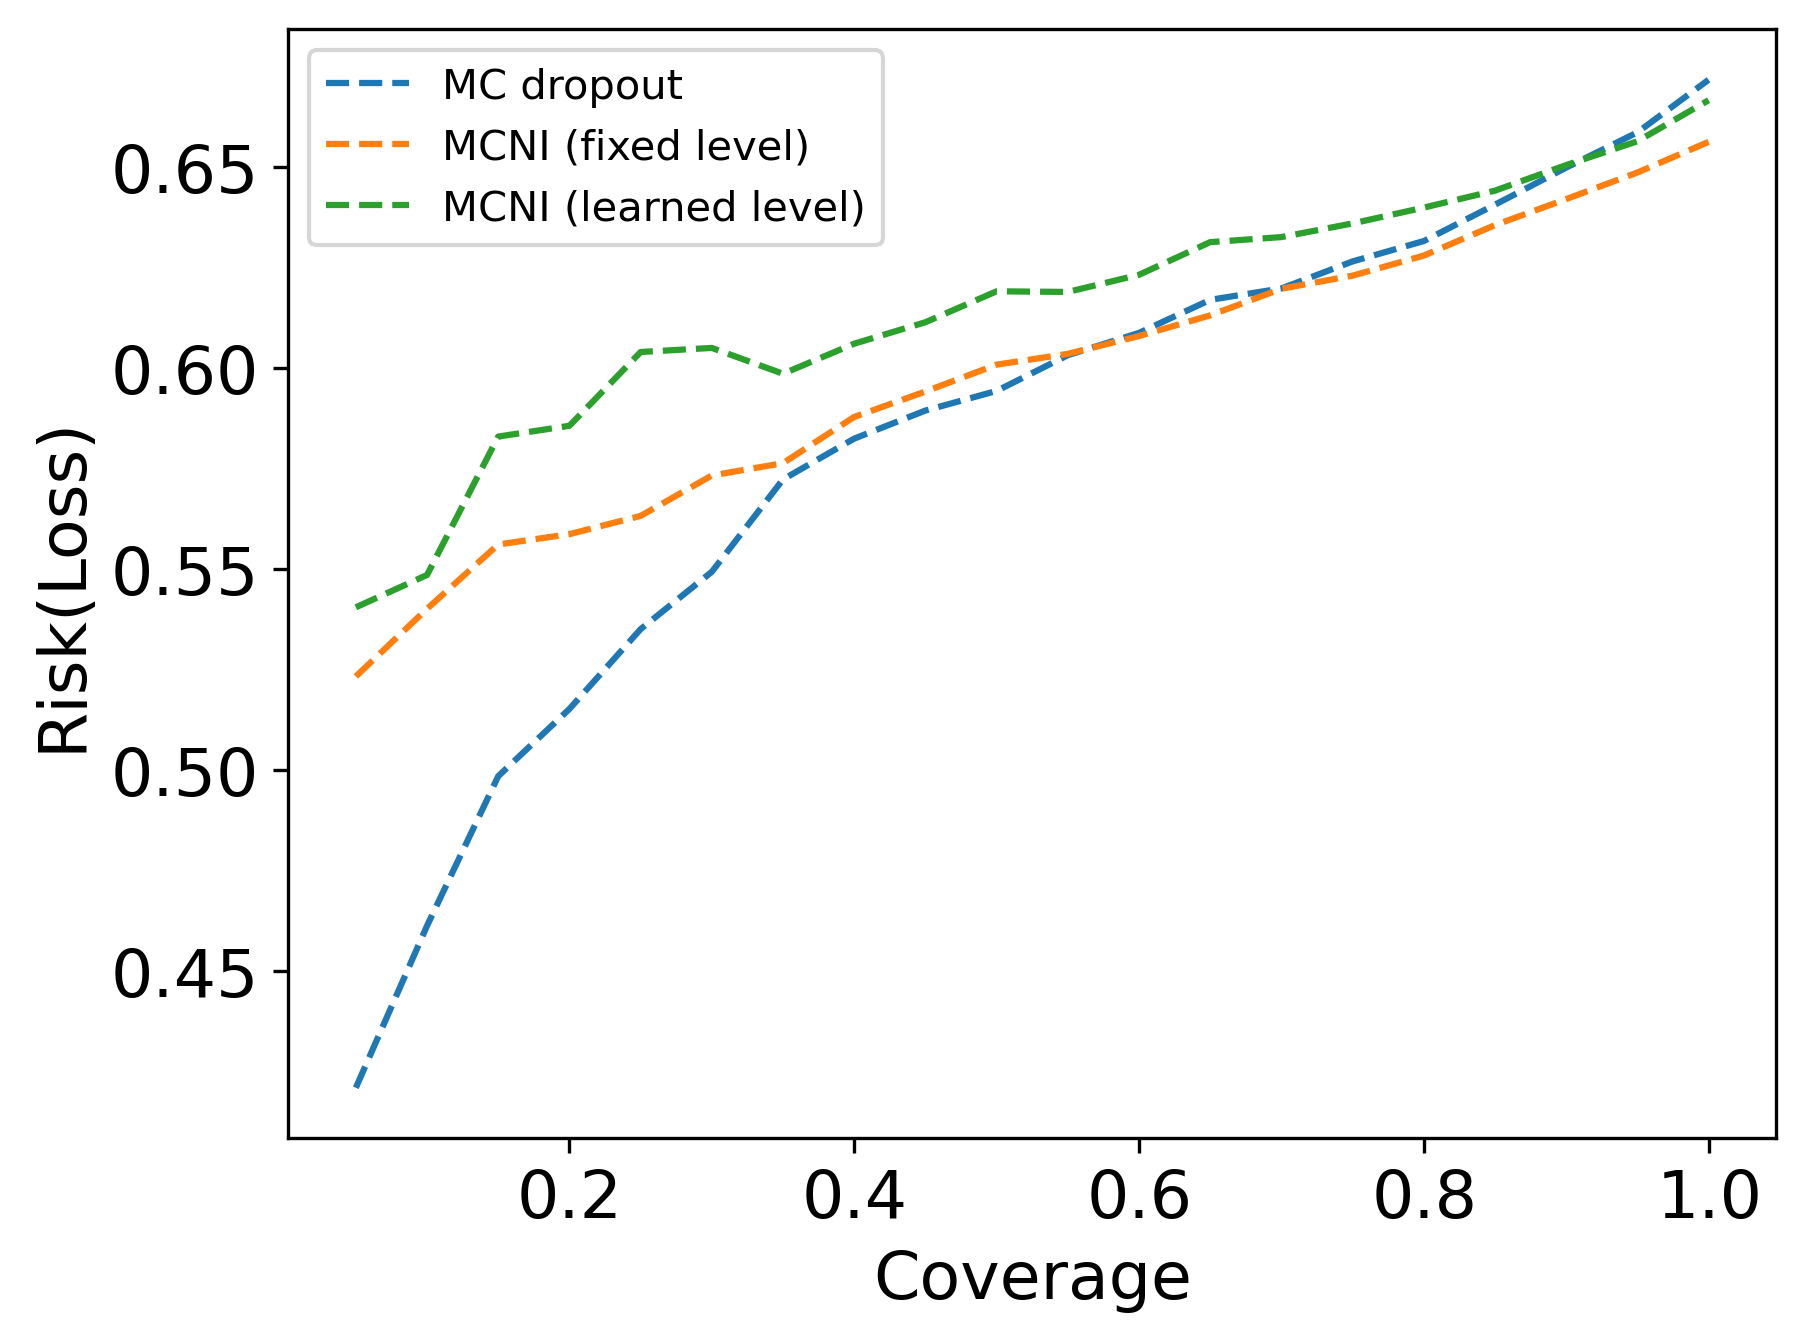

In [8]:
plt.figure(dpi=300)
for model_name in ['dropoutFCN', 'fixnoiseFCN', 'noisyFCN']:
    filename = [filename for filename in filenames if dataset_name+'_'+model_name in filename][0]
    dataset_name, _, batch_size, weight_decay, learning_rate, fix_noiselevel, init_noiselevel, dropout_prob, _ = filename.split('_')
    batch_size, weight_decay, learning_rate, fix_noiselevel, init_noiselevel, dropout_prob = int(batch_size), float(weight_decay), float(learning_rate), float(fix_noiselevel), float(init_noiselevel), float(dropout_prob)
    model = def_model(model_name, input_size, hidden_sizes, output_size, init_noiselevel, fix_noiselevel, dropout_prob)
    checkpoint = torch.load(os.path.join('./save_model', filename))
    model.load_state_dict(checkpoint['state_dict'])
    if use_cuda:
        model = model.cuda()
    loss, var_outputs_all, pred_all = validate(model, test_loader, criterion, test_times=100)
    sorted_index = np.argsort(var_outputs_all)
    total_num = len(sorted_index)
    y_pre_array = np.array(pred_all)
    y_test = np.array(test_data.tensors[1])
    sorted_y_pred = y_pre_array[sorted_index]  # 从预测方差从小到大排序
    sorted_y_data = y_test[sorted_index]
    loss_list = []

    for i in range(1, total_num + 1):
        sorted_y_pred1 = sorted_y_pred[0:i]
        sorted_y_data1 = sorted_y_data[0:i]
        loss_ = criterion(torch.tensor(sorted_y_pred1), torch.tensor(sorted_y_data1))
        loss_ = float(loss_)
        loss_list.append(loss_)
    epochs = np.arange(total_num)
    # 根据输出方差排序样本后，前n个样本输出均值的平均accuracy
    x = (epochs + 1)/len(epochs)
    y = np.asarray([np.sqrt(loss) for loss in loss_list])
    start_idx = int(len(x)*0.1)
    show_range = range(int(len(x)*0.05), len(x), int(len(x)*0.05))
    plt.plot(x[show_range], y[show_range], label=get_fig_label(model_name), linestyle='--')  # bo:blue dot蓝点
plt.legend()
plt.xlabel('Coverage', fontsize=16)
plt.ylabel('Risk(Loss)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.xlim(0.05)
# plt.ylim(5, 6.3)
plt.show()